In [1]:
%cd ..

/Users/sachaquayle/Desktop/hawkes-vm/python/gvm model (article1)/GitHub


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.optimize import minimize
from scipy.stats import kstest, expon
import time
from numba import njit
import pandas as pd
import pickle as pkl
import copy
import random
import importlib
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, BoundaryNorm
from matplotlib.colors import ListedColormap
import seaborn as sns
from collections import defaultdict
np.set_printoptions(threshold=np.inf)
import pickle

import ClassGVM
importlib.reload(ClassGVM)
from ClassGVM import logit, der_logit, negloglikelihood_with_grad_single_jit
from ClassGVM import ExponentialHawkesGVM

In [3]:
%cd data

with open("scripts_and_data/7_trials.txt", "r") as file:
    file_content = file.read()
exec(file_content)

# trials : original 7 trials on [0,10]

with open("scripts_and_data/data_61.txt", "r") as file:
    file_content = file.read()
exec(file_content)

# resampled trials : 25 resamples of the 7 trials on [0,10]

/Users/sachaquayle/Desktop/hawkes-vm/python/gvm model (article1)/GitHub/data


In [6]:
colors = ["#ff8a8e", "white", "#00ff2c"]
custom_cmap_real = LinearSegmentedColormap.from_list("custom_cmap", colors)

def plot_res_x_gvm(model, average=True): 
    subtitles = ['mu', 'alpha', 'beta', 'alpha tilde']
    fig,ax=plt.subplots(2,2,figsize=(10,10))

    if average:
        mu_chap, alpha_chap, beta_chap, alpha_tilde_chap = model.average_estimation
    else:
        mu_chap, alpha_chap, beta_chap, alpha_tilde_chap = model.estimation
        
    ax[0,0].stem(mu_chap)
    ax[0,0].set_title(subtitles[0])
    
    ax[1,0].stem(beta_chap)
    ax[1,0].set_title(subtitles[2])

    sns.heatmap(alpha_chap, cmap=custom_cmap_real, center=0, ax=ax[0,1])
    ax[0,1].set_title(subtitles[1])
    
    sns.heatmap(alpha_tilde_chap, cmap=custom_cmap_real, center=0, ax=ax[1,1])
    ax[1,1].set_title(subtitles[3])

def plot_res_x(model, average=True): 
    subtitles = ['mu', 'alpha', 'beta']
    fig,ax=plt.subplots(2,2,figsize=(10,10))

    if average:
        mu_chap, alpha_chap, beta_chap = model.average_estimation
    else:
        mu_chap, alpha_chap, beta_chap = model.estimation
    
    ax[0,0].stem(mu_chap)
    ax[0,0].set_title(subtitles[0])
    
    ax[1,0].stem(beta_chap)
    ax[1,0].set_title(subtitles[2])

    sns.heatmap(alpha_chap, cmap=custom_cmap_real, center=0, ax=ax[0,1])
    ax[0,1].set_title(subtitles[1])

def plot_bool_matrix_heatmap(matrix, colors):
    """
    Plots a heatmap for a boolean matrix.

    Parameters:
    - matrix: 2D numpy array of booleans.
    - colors: List of 2 colors [False color, True color].
    """
    # Define a custom colormap
    cmap = ListedColormap(colors)

    # Convert boolean matrix to integers (False=0, True=1)
    data = matrix.astype(int)

    # Create the heatmap
    plt.figure(figsize=(8, 6))
    plt.imshow(data, cmap=cmap, aspect='auto')

    # Add gridlines and labels
    plt.colorbar(ticks=[0, 1], label="State")
    plt.clim(-0.5, 1.5)
    plt.title("Boolean Matrix Heatmap")
    plt.xlabel("Columns")
    plt.ylabel("Rows")

    # Show the plot
    plt.show()

# HP

## First estimation

In [5]:
with open("scripts_and_data/first_estimation_61_hp.txt", "r") as file:
    file_content = file.read()
exec(file_content)

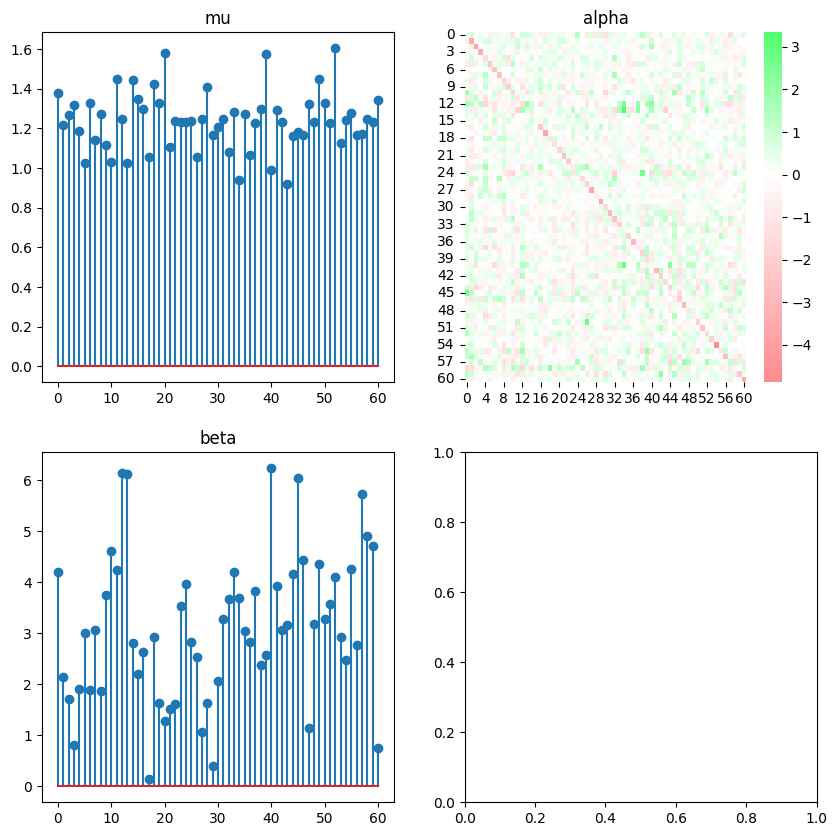

In [6]:
hp = ExponentialHawkesGVM(model='hp')

hp.multiple_estimations = hp_estimations
hp.average_estimation = hp_average_estimation

plot_res_x(hp)

## Final estimation

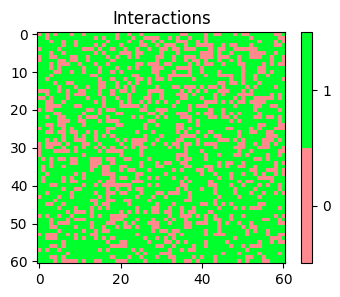

In [20]:
colors = ["#ff8a8e", "#00ff2c"]
cmap = ListedColormap(colors)
data = (~interaction_matrix_cfst).astype(int)

plt.figure(figsize=(4, 3))
plt.imshow(data, cmap=cmap, aspect='auto')

cbar = plt.colorbar(ticks=[0, 1])
cbar.ax.set_yticklabels(['False', 'True'])  # Custom labels
plt.clim(-0.5, 1.5)
plt.title("Interactions")

# Show the plot
plt.show()

In [9]:
with open("scripts_and_data/61_hp_cfst_nonaverage.txt", "r") as file:
    file_content = file.read()
exec(file_content)

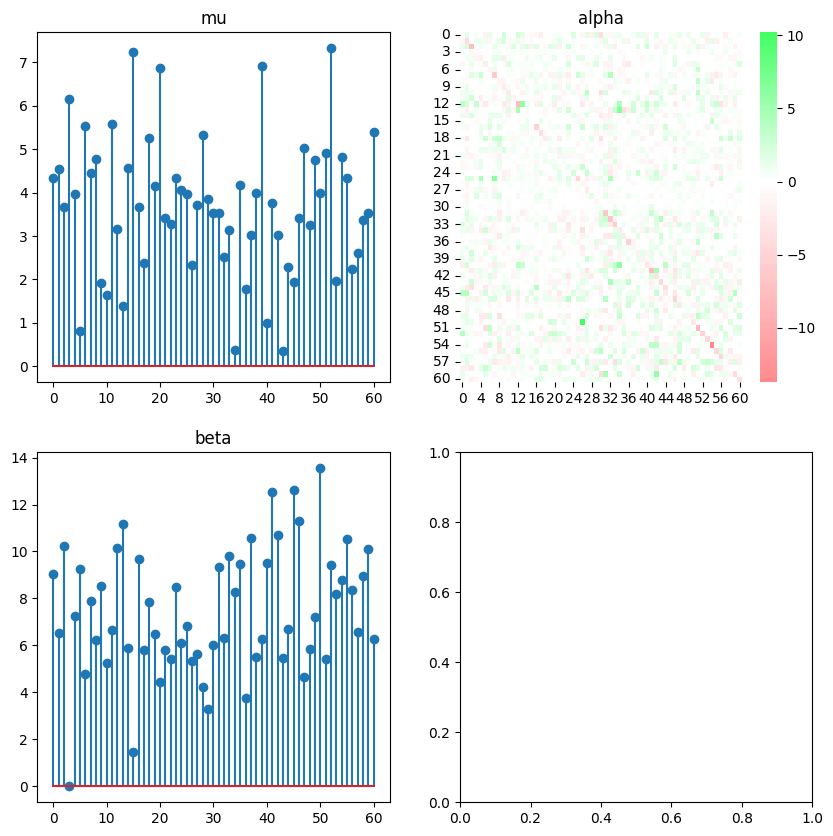

In [10]:
hp = ExponentialHawkesGVM(model='hp')

hp.estimation = hp_estimation

plot_res_x(hp, average=False)

In [11]:
np.mean(hp_pvalues)

np.float64(0.000441429652714566)

# VM

## First estimation

In [12]:
with open("scripts_and_data/first_estimation_61_vm.txt", "r") as file:
    file_content = file.read() 
exec(file_content)

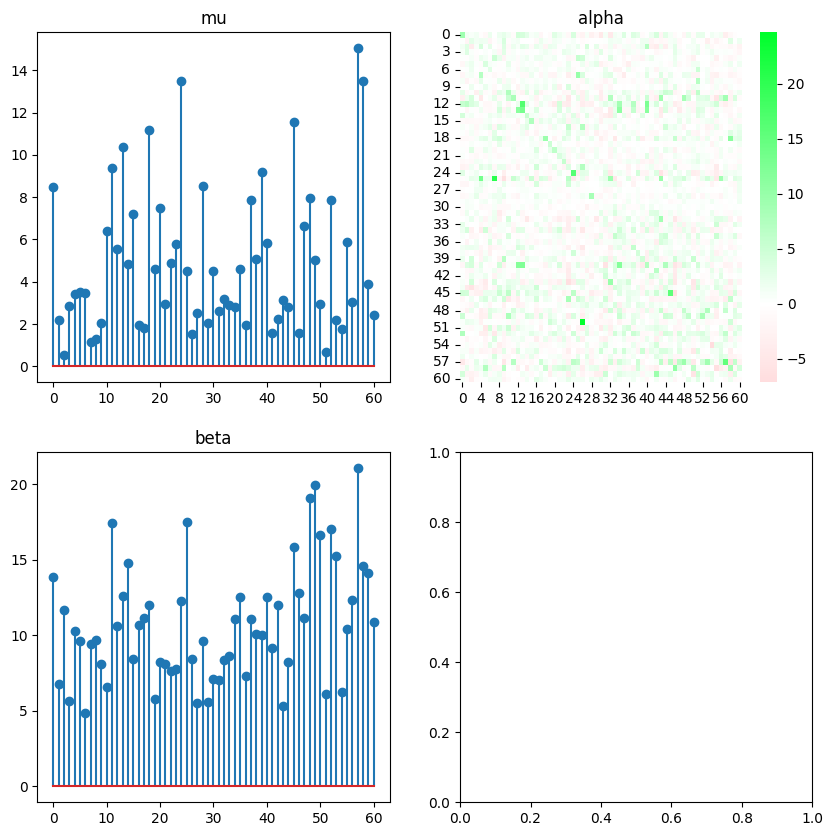

In [13]:
vm = ExponentialHawkesGVM(model='vm')

hp.multiple_estimations = vm_estimations
vm.average_estimation = vm_average_estimation

plot_res_x(vm)

## Final estimation

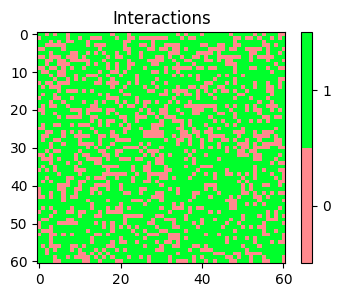

In [14]:
colors = ["#ff8a8e", "#00ff2c"]
cmap = ListedColormap(colors)
data = (~interaction_matrix_cfst).astype(int)

plt.figure(figsize=(4, 3))
plt.imshow(data, cmap=cmap, aspect='auto')

cbar = plt.colorbar(ticks=[0, 1])
cbar.ax.set_yticklabels(['False', 'True'])  # Custom labels
plt.clim(-0.5, 1.5)
plt.title("Interactions")

# Show the plot
plt.show()

In [15]:
with open("scripts_and_data/61_vm_cfst_nonaverage.txt", "r") as file:
    file_content = file.read()
exec(file_content)

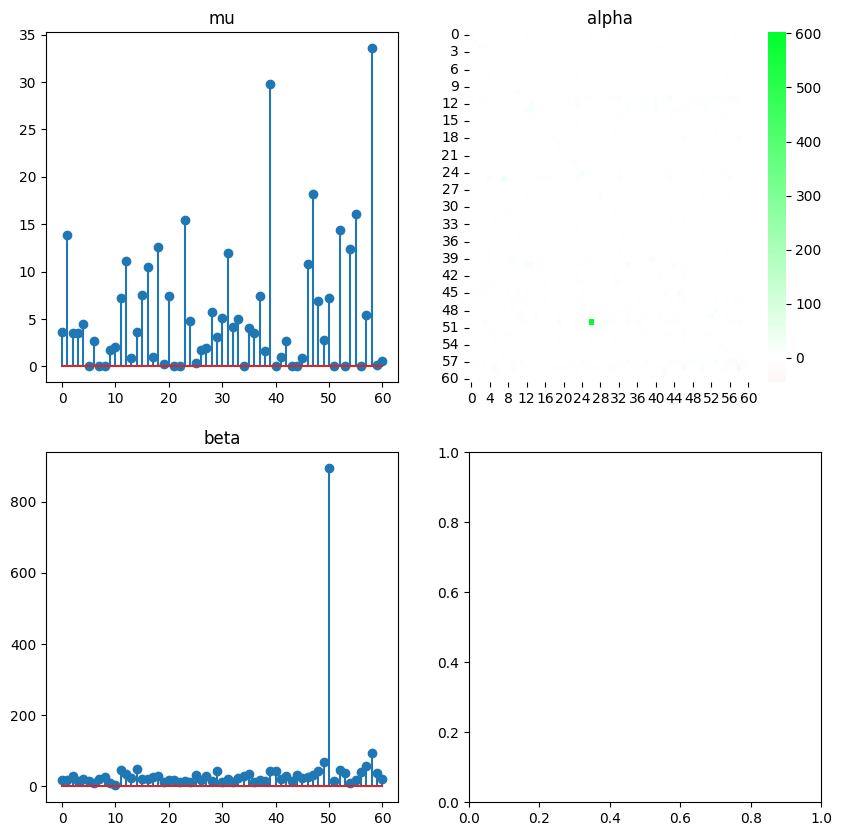

In [16]:
vm = ExponentialHawkesGVM(model='vm')

vm.estimation = vm_estimation

plot_res_x(vm, average=False)

In [17]:
np.mean(vm_pvalues)

np.float64(0.010358272195560674)

# GVM

## First estimation

In [10]:
with open("scripts_and_data/first_estimation_61_gvm.txt", "r") as file:
    file_content = file.read()
exec(file_content)

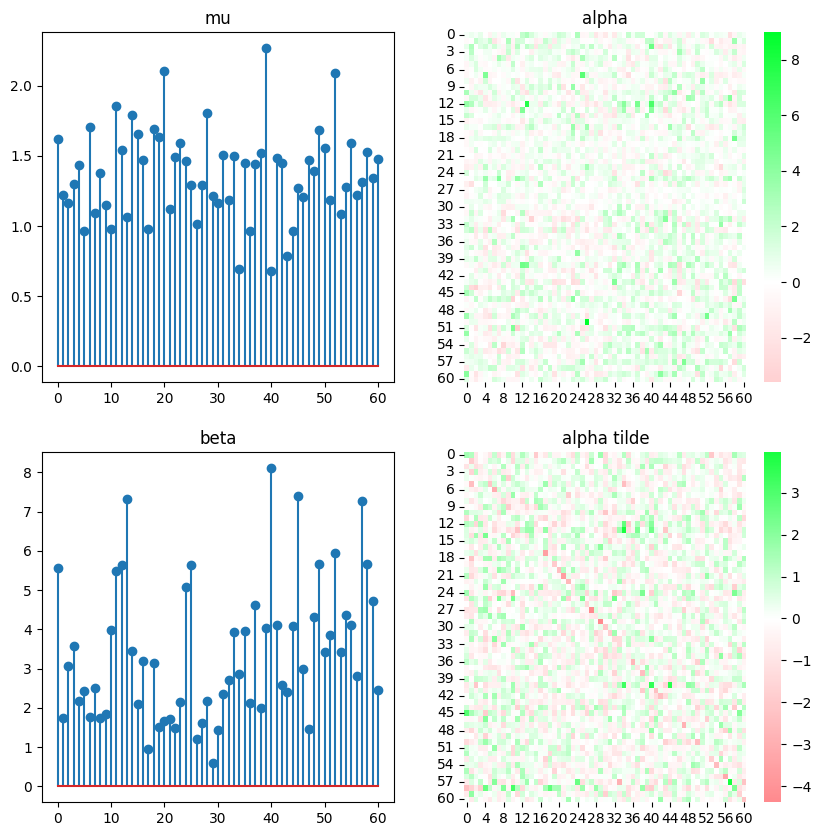

In [19]:
gvm = ExponentialHawkesGVM(model='gvm')

gvm.multiple_estimations = gvm_estimations
gvm.average_estimation = gvm_average_estimation

plot_res_x_gvm(gvm)

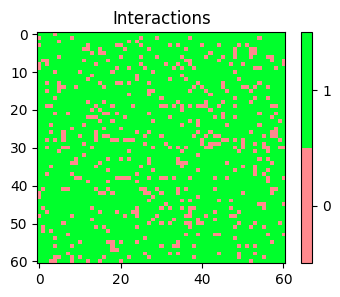

In [20]:
colors = ["#ff8a8e", "#00ff2c"]
cmap = ListedColormap(colors)
data = (~interaction_matrix_cfst).astype(int)

plt.figure(figsize=(4, 3))
plt.imshow(data, cmap=cmap, aspect='auto')

cbar = plt.colorbar(ticks=[0, 1])
cbar.ax.set_yticklabels(['False', 'True'])  # Custom labels
plt.clim(-0.5, 1.5)
plt.title("Interactions")

# Show the plot
plt.show()

## Second estimation

In [11]:
with open("scripts_and_data/second_estimation_61_gvm_cfst.txt", "r") as file:
    file_content = file.read()
exec(file_content)

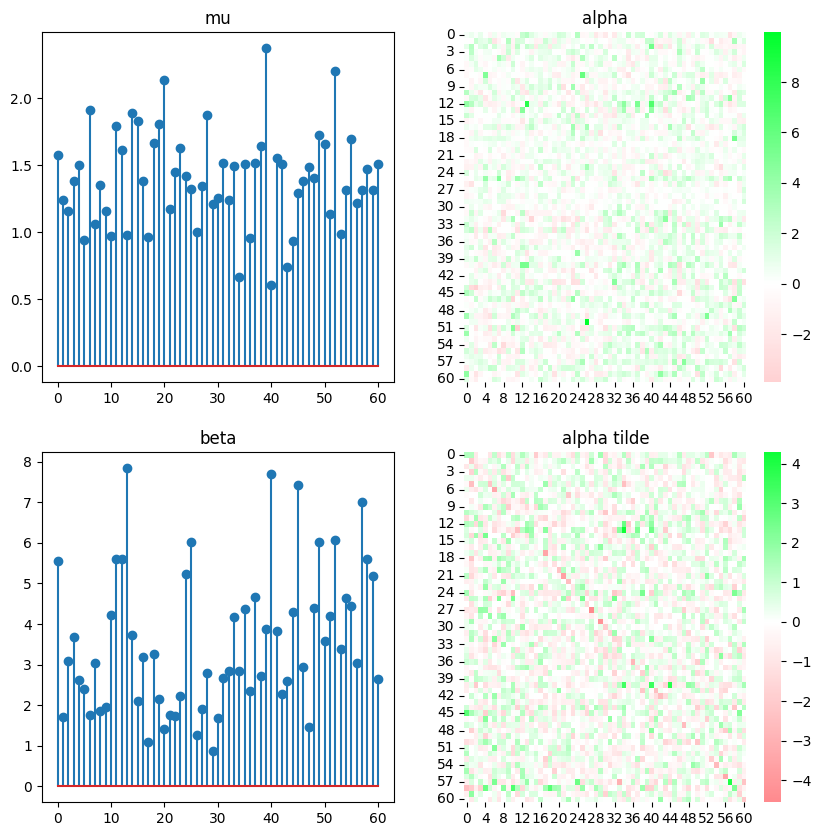

In [22]:
gvm = ExponentialHawkesGVM(model='gvm')

gvm.multiple_estimations = gvm_estimations
gvm.average_estimation = gvm_average_estimation

plot_res_x_gvm(gvm)

## Final estimation

In [7]:
with open("scripts_and_data/61_gvm_cfst_nonaverage.txt", "r") as file:
    file_content = file.read()
exec(file_content)

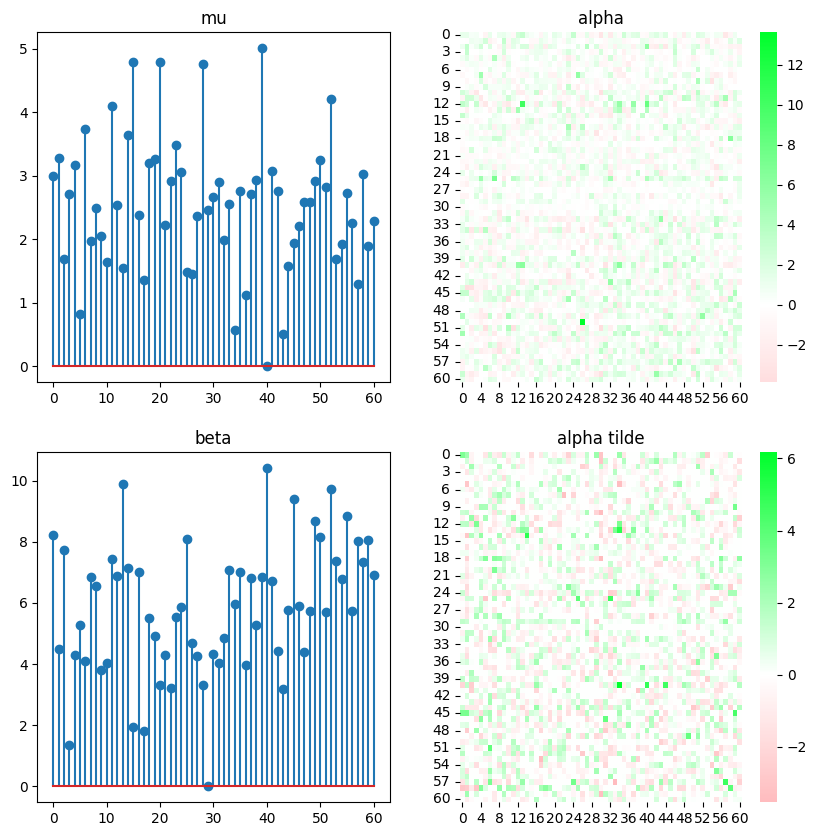

In [8]:
gvm = ExponentialHawkesGVM(model='gvm')

gvm.estimation = gvm_estimation

plot_res_x_gvm(gvm, average=False)

## Recap

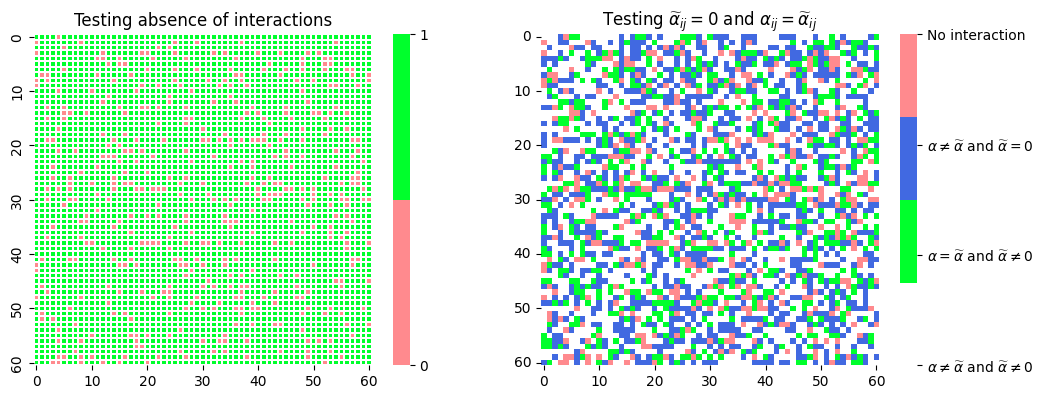

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))

# Interactions
colors = ["#ff8a8e", "#00ff2c"]
cmap = ListedColormap(colors)
data = (~interaction_matrix_cfst).astype(int)

sns.heatmap(
    data,
    cmap=cmap,
    ax=axes[0],
    cbar=True,
    linewidths=0.01,
    linecolor='white',
    cbar_kws={'ticks': [0, 1]},
    xticklabels=10,
    yticklabels=10
)

axes[0].set_title("Testing absence of interactions")


# Tests


data_hp = gvm_hp_matrix_cfst.astype(int)
data_vm = gvm_vm_matrix_cfst.astype(int)

heatmap_data = np.zeros_like(data_vm, dtype=int)
heatmap_data[(data_vm == 1) & (data_hp == 1)] = 3  
heatmap_data[(data_vm == 1) & (data_hp == 0)] = 2  
heatmap_data[(data_vm == 0) & (data_hp == 1)] = 1  
heatmap_data[(data_vm == 0) & (data_hp == 0)] = 0  

heatmap_colors = ["white", "#00ff2c","#4169e1","#ff8a8e"]
cmap_custom = ListedColormap(heatmap_colors)

ax = sns.heatmap(heatmap_data, cmap=cmap_custom, cbar_kws={"ticks": range(4)}, ax=axes[1])

cbar = ax.collections[0].colorbar
cbar.set_ticks(range(4))
cbar.set_ticklabels([
    r"$\alpha\neq\widetilde\alpha$ and $\widetilde\alpha\neq 0$",
    r"$\alpha=\widetilde\alpha$ and $\widetilde\alpha\neq 0$",
    r"$\alpha\neq\widetilde\alpha$ and $\widetilde\alpha = 0$",
    r"No interaction"
])

axes[1].set_title(r"Testing $\widetilde\alpha_{ij}=0$ and $\alpha_{ij}=\widetilde\alpha_{ij}$")

axes[1].set_xticks(axes[0].get_xticks())
axes[1].set_xticklabels(axes[0].get_xticklabels(), rotation=0)  # Pas penché

axes[1].set_yticks(axes[0].get_yticks())
axes[1].set_yticklabels(axes[0].get_yticklabels())

plt.show()


In [18]:
print('Number of VM interactions:', np.sum(heatmap_data==2))
print('Number of HP interactions:', np.sum(heatmap_data==1))
print('Number of interactions which are neither HP nor VM:', np.sum(heatmap_data==0))

Number of VM interactions: 1045
Number of HP interactions: 630
Number of interactions which are neither HP nor VM: 1589


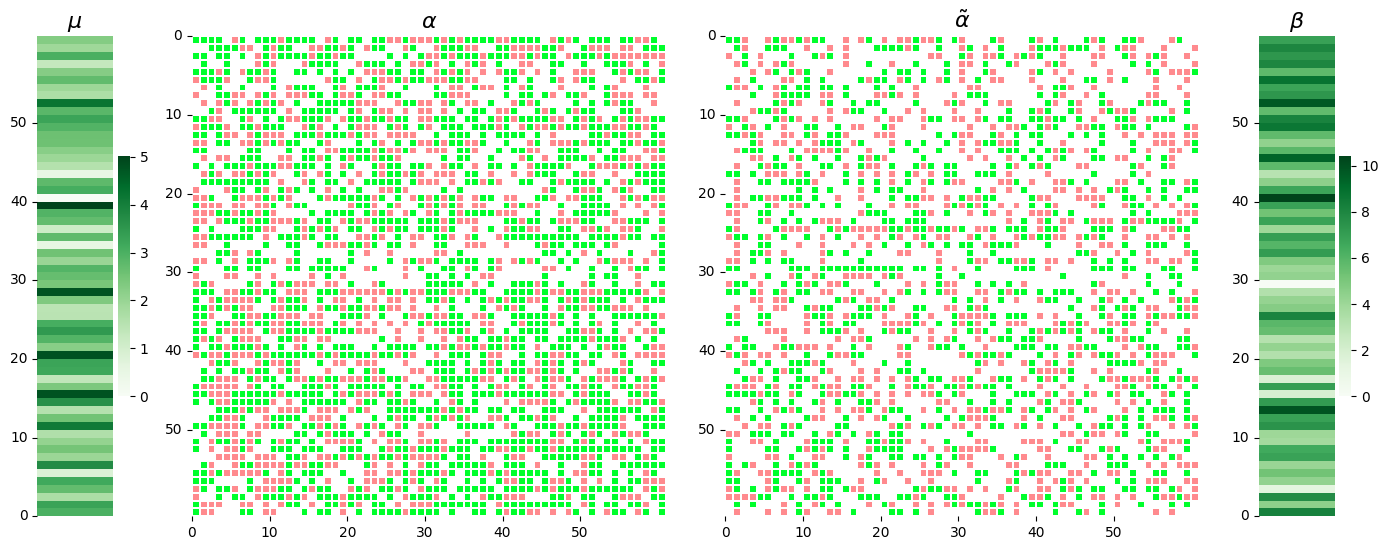

In [28]:
mu,alpha,beta,alpha_tilde = gvm_estimation
n=len(mu)

cmap = ListedColormap(["#ff8a8e", "white", "#00ff2c"])
bounds = [-np.inf, 0, np.inf]  
norm = plt.Normalize(vmin=-1, vmax=1)  

fig, axes = plt.subplots(1, 4, figsize=(14, 5.6), gridspec_kw={'width_ratios': [0.2, 1, 1, 0.2]})

sns.heatmap(mu[:, np.newaxis], cmap="Greens", ax=axes[0], cbar=True, cbar_kws={"shrink": 0.5})
axes[0].set_title(r"$\mu$",fontsize=16)
axes[0].set_yticks(10*np.arange(data.shape[1]//10))
axes[0].set_yticklabels(10*np.arange(data.shape[1]//10))
axes[0].set_xticks([])
axes[0].invert_yaxis()

sns.heatmap(alpha, cmap=cmap, norm=norm, ax=axes[1], cbar=False,     linewidths=0.3,
    linecolor='white')
axes[1].set_title(r"$\alpha$",fontsize=16)
axes[1].set_xticks(10*np.arange(data.shape[1]//10))
axes[1].set_xticklabels(10*np.arange(data.shape[1]//10))
axes[1].set_yticks(10*np.arange(data.shape[1]//10))
axes[1].set_yticklabels(10*np.arange(data.shape[1]//10))

sns.heatmap(alpha_tilde, cmap=cmap, norm=norm, ax=axes[2], cbar=False, linewidths=0.3,
    linecolor='white')
axes[2].set_title(r"$\tilde{\alpha}$",fontsize=16)
axes[2].set_xticks(10*np.arange(data.shape[1]//10))
axes[2].set_xticklabels(10*np.arange(data.shape[1]//10))
axes[2].set_yticks(10*np.arange(data.shape[1]//10))
axes[2].set_yticklabels(10*np.arange(data.shape[1]//10))

sns.heatmap(beta[:, np.newaxis], cmap="Greens", ax=axes[3], cbar=True, cbar_kws={"shrink": 0.5})
axes[3].set_title(r"$\beta$",fontsize=16)
axes[3].set_yticks(10*np.arange(data.shape[1]//10))
axes[3].set_yticklabels(10*np.arange(data.shape[1]//10))
axes[3].set_xticks([])
axes[3].invert_yaxis()

plt.tight_layout()
plt.show()

In [29]:
np.mean(gvm_pvalues)

np.float64(0.051581561895252)

# Recap of final pvalues

In [30]:
a = [['HP:', np.mean(hp_pvalues)],
     ['VM:', np.mean(vm_pvalues)],
     ['GVM:', np.mean(gvm_pvalues)]]
from tabulate import tabulate
headers = ["Method", "p-value"]
print('For CfST + sum, resampling:\n',
        tabulate(a, headers=headers, tablefmt="grid"))

For CfST + sum, resampling:
 +----------+------------+
| Method   |    p-value |
+==========+============+
| HP:      | 0.00044143 |
+----------+------------+
| VM:      | 0.0103583  |
+----------+------------+
| GVM:     | 0.0515816  |
+----------+------------+
